In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv


# Polynomial Regression

Polynomial Regression is a supervised machine learning algorithm used for predicting a continuous target variable when the relationship between the input and output is **non-linear**.

In Simple Linear Regression, we assume that the relationship between the independent variable and dependent variable can be represented using a straight line:

$$
y = b_0 + b_1x
$$

However, real-world relationships are not always linear. When the data follows a curved pattern, Polynomial Regression can provide a better fit.

The general polynomial equation is:

$$
y = b_0 + b_1x + b_2x^2 + b_3x^3 + \cdots + b_nx^n
$$

Here:

* $x$ → independent variable
* $y$ → dependent variable
* $b_0$ → intercept
* $b_1, b_2, \ldots, b_n$ → coefficients
* $n$ → degree of the polynomial


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [7]:
df = pd.read_csv('/kaggle/input/datasets/abhishek14398/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [8]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [12]:
X = df[['YearsExperience']]
y = df['Salary']

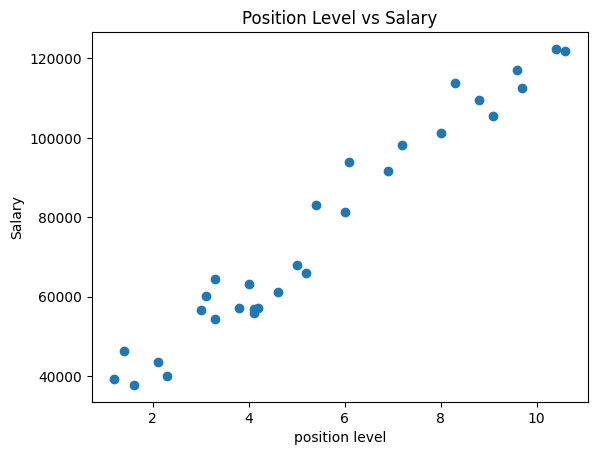

In [13]:
plt.scatter(X,y)
plt.xlabel("position level")
plt.ylabel('Salary')
plt.title('Position Level vs Salary')
plt.show()

In [14]:
poly = PolynomialFeatures(degree=4)
x_poly = poly.fit_transform(X)

In [15]:
x_poly

array([[1.00000000e+00, 1.20000000e+00, 1.44000000e+00, 1.72800000e+00,
        2.07360000e+00],
       [1.00000000e+00, 1.40000000e+00, 1.96000000e+00, 2.74400000e+00,
        3.84160000e+00],
       [1.00000000e+00, 1.60000000e+00, 2.56000000e+00, 4.09600000e+00,
        6.55360000e+00],
       [1.00000000e+00, 2.10000000e+00, 4.41000000e+00, 9.26100000e+00,
        1.94481000e+01],
       [1.00000000e+00, 2.30000000e+00, 5.29000000e+00, 1.21670000e+01,
        2.79841000e+01],
       [1.00000000e+00, 3.00000000e+00, 9.00000000e+00, 2.70000000e+01,
        8.10000000e+01],
       [1.00000000e+00, 3.10000000e+00, 9.61000000e+00, 2.97910000e+01,
        9.23521000e+01],
       [1.00000000e+00, 3.30000000e+00, 1.08900000e+01, 3.59370000e+01,
        1.18592100e+02],
       [1.00000000e+00, 3.30000000e+00, 1.08900000e+01, 3.59370000e+01,
        1.18592100e+02],
       [1.00000000e+00, 3.80000000e+00, 1.44400000e+01, 5.48720000e+01,
        2.08513600e+02],
       [1.00000000e+00, 4.0000

In [16]:
poly_model =  LinearRegression()
poly_model.fit(x_poly,y)

LinearRegression()

In [18]:
y_pred = poly_model.predict(x_poly)

In [25]:
new_level = [[6.5]]

prediction = poly_model.predict(
    poly.transform(new_level)
)

print("Predicted Salary:", prediction[0])

Predicted Salary: 88253.65786533157


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [26]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 26403845.623880092
R² Score: 0.9636560599375091
